In [57]:
import pandas as pd
from Import_data import import_df_description, Make_path_list
from Parameters import subject_to_pop, path_directory, dict_category_all, path_excel, std_bad_epoch, fmin, fmax
from Tools import  find_participant,get_only_eeg, df_to_mne_events2, get_sub_df, get_tmax, filtering, get_idx_bad_epoch, get_mean_interpolate_ch
import mne
from scipy.stats import pearsonr
from autoreject import AutoReject
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def make_epochs(path_data,df_sub,tmax):
    
    """ 
    df_sub = le sous Dataframe contenant uniquement les meta data du sujet en question (moment de la stimuation, temps de production...)
    tmax = temps maximum pour le decoupage des essais en epoch (moyenne des temps de latence sur les essais valides)
    """

    raw = mne.io.read_raw_bdf(path_data, preload=True)          # lecture du fichier .bdf

    raw_eeg = get_only_eeg(raw)                                 # selection des canaux eeg uniquement
    raw_eeg.set_montage("biosemi128")                           # precision du montage utilise
    filtered_eeg = filtering(raw_eeg,fmin,fmax)

    mne_events, stim = df_to_mne_events2(filtered_eeg,df_sub)   # obligatoire pour faire un objet mne.Epochs(), contient les information de debut de stiumulation et de temp de latence   
    epochs_eeg = mne.Epochs(filtered_eeg,events = mne_events,
                            event_id = stim,tmin = -0.2,
                            tmax=tmax,preload=True)             # on utilise le temps de latence moyen (sans les essais trop lents) pour mettre une limite a la taille de la fenetre 
    
    epochs_eeg.set_eeg_reference('average', projection=False)   # on rereference la baseline par rapport a la moyenne
    epochs_eeg.apply_baseline((None, 0))                        # on retire le bruit de la baseline

    epochs_eeg.metadata = df_sub

    ar = AutoReject()
    epochs_eeg_clean = ar.fit_transform(epochs_eeg)                             # retire automatiquement les epochs trop bruitees et les canaux mauvais
    log = ar.get_reject_log(epochs_eeg)                                         # recuperation des informations sur le nettoyage                                                      
    idx_bad_epoch = get_idx_bad_epoch(log.bad_epochs)                           # epochs rejetés
    mean_interpolate_ch = get_mean_interpolate_ch(idx_bad_epoch,log.labels)     # quels canaux étaient mauvais et ont ete interpoles

    return epochs_eeg, epochs_eeg_clean, idx_bad_epoch, mean_interpolate_ch

def make_dict_epochs(df,list_path_data,std_bad_epoch = std_bad_epoch):
                                                   
    tmax = get_tmax(df,std_bad_epoch)                                           # utile pour definir la taille des epochs base sur le temps de latence moyen des essais valides

    dict_epochs = {}
    path_data = list_path_data[0]
    sub = find_participant(path_data)
    sub_df = get_sub_df(df,sub)
    dict_epochs[sub] = make_epochs(path_data,sub_df,tmax = tmax)

    return dict_epochs






In [59]:
list_path_data, path_stim, path_answers = Make_path_list(path_directory,subject_to_pop)
df = import_df_description(path_stim,path_answers,dict_category_all,path_excel,subject_to_pop)
    
dico  = make_dict_epochs(df,list_path_data)

c:\Users\hugop\Desktop\Code_Iconic\Scripts\simulation_V2\Import_data.py:201: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sommail"] = df["sommail"].replace(map)


Extracting BDF parameters from C:\Users\hugop\Desktop\Stage Iconique\Data_stage\EEG data\S01_DS.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 564735  =      0.000 ...  1102.998 secs...


c:\Users\hugop\Desktop\Code_Iconic\Scripts\simulation_V2\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_tw[col] = list(sub_df_p[col])[0]
c:\Users\hugop\Desktop\Code_Iconic\Scripts\simulation_V2\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_tw[col] = list(sub_df_p[col])[0]
c:\Users\hugop\Desktop\Code_Iconic\Scripts\simulation_V2\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3381 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband ed

  0%|          | Creating augmented epochs : 0/128 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/131 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.20 and n_interpolate=4


  0%|          | Repairing epochs : 0/131 [00:00<?,       ?it/s]

Dropped 64 epochs: 0, 1, 2, 3, 6, 7, 10, 11, 13, 14, 24, 26, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 60, 61, 62, 63, 64, 67, 68, 70, 82, 84, 85, 98, 109, 112, 115, 116, 117, 118, 119, 120, 122, 124, 125, 126, 130
nb d'epoch = 131
nb de bad epoch = 64
nb moyen de ch interpolee = 4.556902985074627


In [60]:
dico['S01'][1]

# 39,7.32
# 14, 2.1
# 66, 3.8

<Epochs | 67 events (all good), -0.199 – 0.953 s (baseline -0.199 – 0 s), ~38.8 MiB, data loaded, with metadata,
 np.str_('A'): 16
 np.str_('B'): 38
 np.str_('C'): 13>

In [61]:
eeg = dico["S01"][0]
eeg_clean = dico["S01"][1]
bad_epoch = dico["S01"][2]
mean_bad_ch = dico["S01"][3]

print(f"nb d'epoch suprimees = {len(bad_epoch)}")
print(f"nb moyen de cannaux interpolee = {mean_bad_ch}")

nb d'epoch suprimees = 64
nb moyen de cannaux interpolee = 4.556902985074627


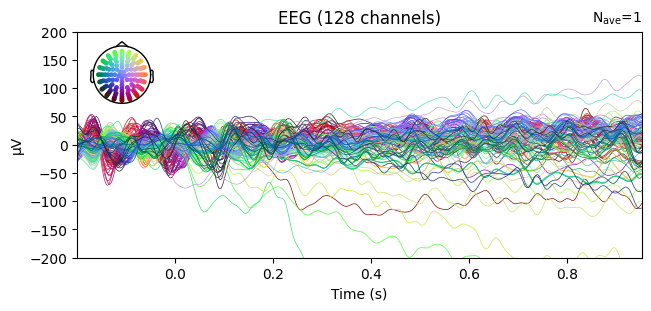

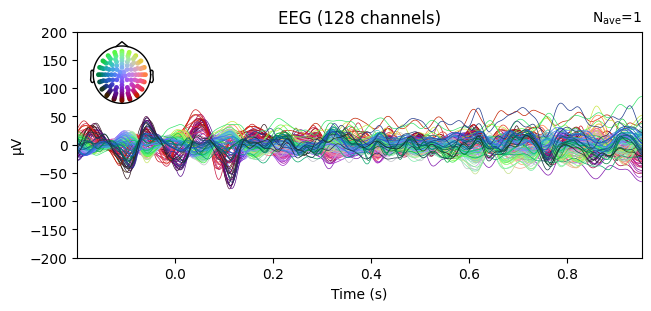

In [62]:
eeg[bad_epoch[9]].average().plot(ylim=dict(eeg=[-200, 200]))
eeg_clean[[5]].average().plot(ylim=dict(eeg=[-200, 200]))
print()

Average sans nettoyage


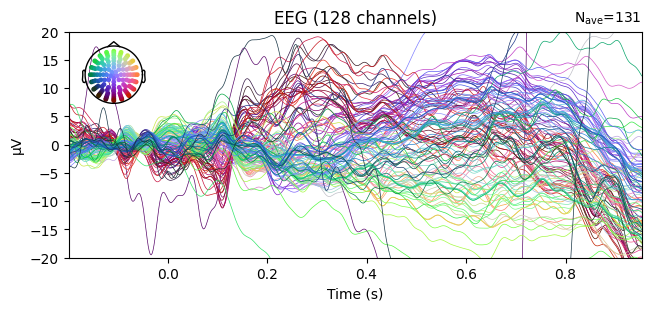

In [63]:
print("Average sans nettoyage")
eeg.average().plot(ylim=dict(eeg=[-20, 20]))
print()

Average avec nettoyage


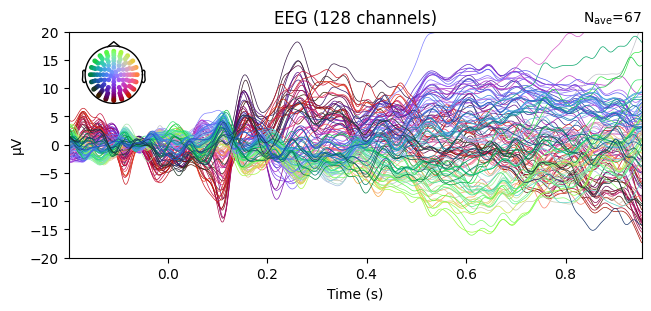

In [64]:
print("Average avec nettoyage")
eeg_clean.average().plot(ylim=dict(eeg=[-20, 20]))
print()
